In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aotools.turbulence import r0_to_cn2,cn2_to_r0

# Butterley code for theoretical slope weighting functions (integral method):

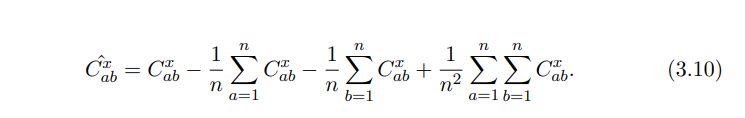

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 3.10

Code obtained courtesy of Butterley for theoretical SLODAR autocovariance, translated from C to Python and modified to output covariance only for a single star.

---

**The result is used as ground truth for the Fourier-based tests.**


In [38]:
import numpy as np

def kol_strucfunc(r, r0=1.0):
    # 6.88*(r/r0)^(5/3)
    return 6.88 * (r / r0) ** (5.0 / 3.0)

def slopecov_kol(nsubx: int, nsamp: int, d: float):
    """
    slodar_slopecovKol2(nsubx, nsamp, d) wrapper for Python.
    return cov con shape: (2, nn, nn) where nn = 2*nsubx-1 cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  
    cov[1, di, dj] -> cov_yy 
    """

    nn = 2 * nsubx - 1
    cov = np.zeros((2, nn, nn), dtype=np.float64)

    # from C: sub-aperture coords in [-0.5,0.5)  offset of 0.5/nsamp
    rxy = (np.arange(nsamp) - (nsamp / 2) + 0.5) / nsamp
    tilt = 2.0 * np.sqrt(3.0) * rxy  # tilt[i] = 2*sqrt(3)*rxy[i]

    # from C (hard-wired lam=500nm and r0=d)
    scaling = (206265.0 ** 2) * 3.0 * (500e-9 / (np.pi * d)) ** 2
    n2 = nsamp * nsamp
    n4 = n2 * n2
 
    
    # Integral method for slopes weighting functions

    for i in range(nn):
        for j in range(nn):
            ra_intgrl = np.zeros((nsamp, nsamp), dtype=np.float64)
            rb_intgrl = np.zeros((nsamp, nsamp), dtype=np.float64)
            D_phi = np.zeros((nsamp, nsamp, nsamp, nsamp), dtype=np.float64)

            dbl_intgrl = 0.0

            # 1) build D_phi and acumulation of partial integrals (ra, rb) + total integration 
            for ia in range(nsamp):
                for ja in range(nsamp):
                    for ib in range(nsamp):
                        for jb in range(nsamp):
                            x = (i - nsubx + 1) - rxy[ia] + rxy[ib]
                            y = (j - nsubx + 1) - rxy[ja] + rxy[jb]
                            r = np.sqrt(x * x + y * y)
                            val = kol_strucfunc(r, r0=1.0)
                            D_phi[ia, ja, ib, jb] = val

                            ra_intgrl[ib, jb] += val
                            rb_intgrl[ia, ja] += val
                            dbl_intgrl += val

            # 2) build phiphi and acumulation of tilt covariance on x and y
            xtiltcov = 0.0
            ytiltcov = 0.0
            mean_dbl = dbl_intgrl / (nsamp ** 4)

            for ia in range(nsamp):
                for ja in range(nsamp):
                    for ib in range(nsamp):
                        for jb in range(nsamp):

                            # phiphi = 0.5*((ra+rb)/n2) - 0.5*D_phi - 0.5*(dbl/nsamp^4)
                            phiphi = 0.5 * ((ra_intgrl[ib, jb] + rb_intgrl[ia, ja]) / n2)
                            phiphi -= 0.5 * D_phi[ia, ja, ib, jb]
                            phiphi -= 0.5 * mean_dbl

                            xtiltcov += phiphi * tilt[ia] * tilt[ib] * scaling
                            ytiltcov += phiphi * tilt[ja] * tilt[jb] * scaling

            cov[0, i, j] =  xtiltcov / n4   # X-slope cov
            cov[1, i, j] =  ytiltcov / n4   # y-slope cov

    return cov



# Function test:


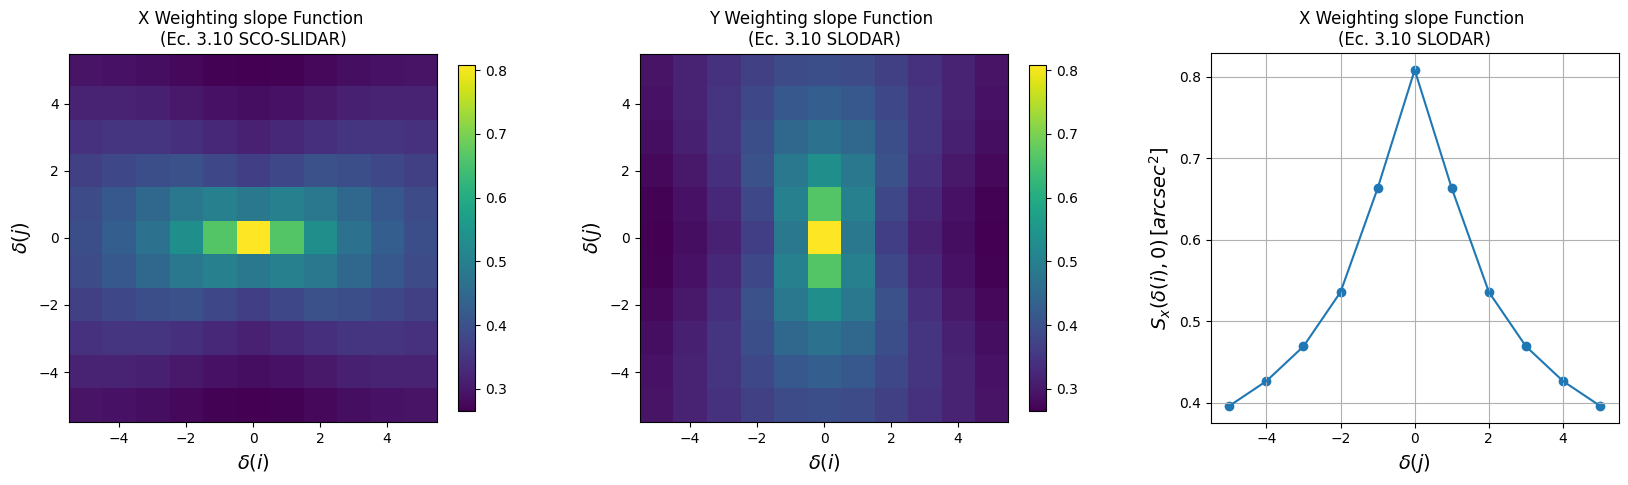

In [74]:
import matplotlib.pylab as plt
# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 
samp = 8    # sampling

tcov = slopecov_kol(nsubx, samp, d) #<-- function call

GRID_SIZE = 2 * nsubx - 1
BEAM = 1


# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 3.10 SCO-SLIDAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 3.10 SLODAR)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,5,:],)
ax3.scatter(np.arange(-5, 6),tcov[0,5,:],)
ax3.set_title('X Weighting slope Function \n(Ec. 3.10 SLODAR)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# Z-tilt filter based on ryan thesis:

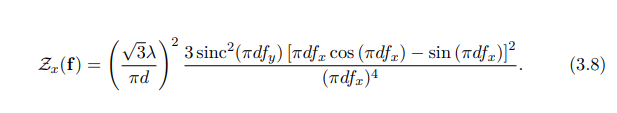

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 3.8 Z-tilt filter


In [2]:
def calculate_Zx_spectral_filter(fx: np.ndarray, fy: np.ndarray, wavelength: float, d: float):
    """
    spectral filter Z_x(f) (Ec. 3.8).
    
    Args:
        fx (ndarray)       : spatial frecuency in X.
        fy (ndarray)       : spatial frecuency in Y.
        d (float)          : sub-aperture size.
        
    Returns:

        Zx(F) (ndarray): spatial filter.
    """
    scalingFactor = ((np.sqrt(3) * wavelength) / (np.pi * d)) ** 2
    y_term = 3 * (np.sinc(d * fy)) ** 2

    # [u*cos(u) - sin(u)]^2 / u^4, where u = pi*d*fx
    u = np.pi * d * fx
    u2 = u*u
    u4 = u2*u2 # @dev_note: I found this way of obtaining u^4 curious but interesting.
    
    # init X term with zeros
    x_term = np.zeros_like(u)
    mask = np.abs(u) > 0 #<-- mask preventing x/0 cases
    
    # numerator: [u cos(u) - sin(u)]^2
    numerator = ( u[mask] * np.cos(u[mask]) - np.sin(u[mask])) ** 2
    
    # [u cos(u) - sin(u)]^2 / u^4
    x_term[mask] = numerator / u4[mask]
    
    Zx =  y_term * x_term * scalingFactor 
    return Zx



# Multy-layer Kolmogorov PSD from equation 2.11 :

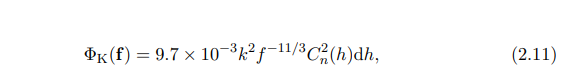

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 2.11 Kolmogorov PSD

---

**@dev_note:** This is where I start to encounter some issues.
The literature contains many interpretations of the PSD equation.
In this case, we use the layer formulation, since it will later be used
to obtain the scintillation weighting function.
Based on SHIMM and the Butterley code, I am guided by their approach,
where the result is the integral over all layers.
For simplification, the Butterley code assumes r0 = 1. This is because,
in the sub-aperture relation, we can take r0 ≈ d.
I am somewhat confused about this, because the equation works with Cn2
for multiple layers, but it is not clear which Cn2 values should be used
for each layer.
In this function I implemented different approaches, some of which are commented out.


In [3]:
def Kolmogorov_PSD(f: np.ndarray, wavelength: float, glob: bool, r0=1.0):
    """
        spectral filter Z_x(f) (Ec. 3.8).
    
        Args:
            f (ndarray)       : spatial frecuency in X.
            r0 float          : strength of the turbulent in the layer  
            glob (Bool)       : if you want to use a Phi_K with a global r0 or not
            
        Returns:

            Phi_K(F) (ndarray): kolmogorov_PSD.
    """

    k = 2 * np.pi / wavelength
    k2 = k*k

    Phi_K = np.zeros_like(f)

    # x/0 prevention
    mask_f = f > 0 

    if glob:
        # kolmogorov PSD Integrated r0 
        Phi_K[mask_f] = 0.023 *(r0 ** (-5/3)) * (f[mask_f] ** (-11/3)) 
       
    else:
        Cn2_dh = r0_to_cn2(r0,wavelength) # asumes a layer with r0 = 1 or any percentge of 1
        # Cn2_dh = 1           # asumes a layer with cn2 = 1

        #Kolmogorov PSD eq (2.11): layer aproach
        Phi_K[mask_f] = 0.0097 * k2 * (f[mask_f] ** (-11/3)) * Cn2_dh

    # piston remove
    Phi_K[0,0] = 0

    return Phi_K



# Fourier filter method for Slopes Weigthing function:

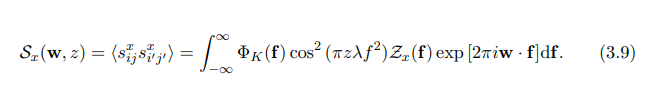

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].
- ref: eq 3.9 Fourier method filter

---

**@dev_note:** My issue here may be related to the handling of the scaling factors.
I notice that in the Butterley code there is a scaling factor, and the function used
for the numerical integration is based on the Zernike function representation shown in the figure below.
Those are spatial representations for the integrated method, whereas in the Fourier approach we work in the spatial-frequency domain.
I assume that in this part we use the MLA grid to create the Fx and Fy input functions($\frac{1}{d \cdot nsubx}$), although I may be confusing these two aspects.

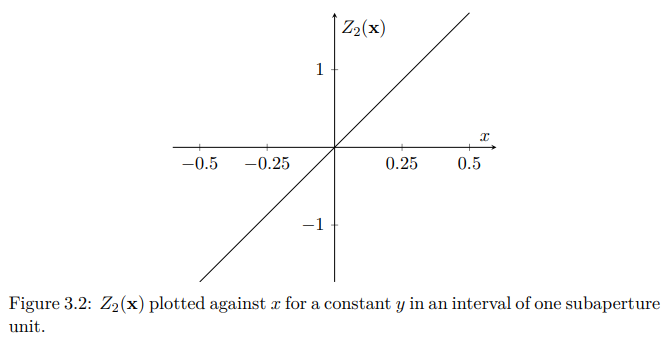

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].


In [90]:

def calculate_weighting_function(d: float, nsubx: int, r0=1, wavelength=500e-9, h=0, glob=False):

    """
    calculate weighting function (cov) for SHIMM.
    
    Args:
        h (float)  : layer altitude    [m].
        d (float)  : sub-aperture size [m].
        glob (Bool): if you want to use a Phi_K with a global r0 or not
        nsubx (int): grid size.

    Returns:
    return  W_z (ndarray): [2,N,N]. where N = 2*nsubx-1 

    cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  
    cov[1, di, dj] -> cov_yy 

    """
    
    # 1. spatio-frequency domain (fx, fy)
    N = 2 * nsubx - 1                #<-- lineal cov implementation [cycles]
    dx = d                           #<-- steps for all sub-aperture grid [m]

    freq = np.fft.fftfreq(N, d=dx)   #<-- spatio-frequency vector based on sub-aperture grid size [1 / (m * cycles)]
    # the fftshift output of freq with nsubx = 6 and d = 0.047 it is: [-1.93:1.93]
    
    fx, fy = np.meshgrid(freq, freq) 

    # spatio-frequency magnitude 
    f = np.hypot(fx,fy)   # f = ||f||
    f2 = f*f

    
    # ---------------------------------------------------------
    
    # 3. Shack-Hartmann aperture filter (Ec. 3.8)
    A_fx = calculate_Zx_spectral_filter(fy, fx, wavelength, d)
    A_fy = calculate_Zx_spectral_filter(fx ,fy ,wavelength, d)
    
    # 4. propagation ( sinusoidal term in Ec. 3.9) fresnel phase param
    Fresnel_term = np.cos(np.pi * wavelength * h * f2)**2

    #5. Kolmogorov PSD obtain (Ec. 2.11)
    Phi_K = Kolmogorov_PSD(f,wavelength,glob,r0)

    # 6. Filter applied
    spectral_densityX =  Phi_K * Fresnel_term * A_fx 
    spectral_densityY =  Phi_K * Fresnel_term * A_fy 

    # 7. ifft
    covariance_mapX = np.fft.ifft2(spectral_densityX)
    covariance_mapY = np.fft.ifft2(spectral_densityY)
    
    covariance_mapX = np.fft.fftshift(covariance_mapX) 
    covariance_mapY = np.fft.fftshift(covariance_mapY) 
    
    scalingFactor = (206265.0)**2 

    # @Dev_Note: actualy, I am not sure if it is necesary to implement this scaling-factor

    W_zX = np.real(covariance_mapX) *  scalingFactor # X slope on [Rad^2] -> [arcsec^2]
    W_zY = np.real(covariance_mapY) *  scalingFactor # Y slope on [Rad^2] -> [arcsec^2]

    
    return np.array([W_zX,W_zY])


# Example:

---
@Dev_note: As you can see, the resulting matrix looks similar, but its scale does not match the Butterley integrated method. I’m not sure whether this is due to a scaling issue, the Kolmogorov PSD method, or simply the spatial-frequency vector being used. These are the parts I expected to see in the code.

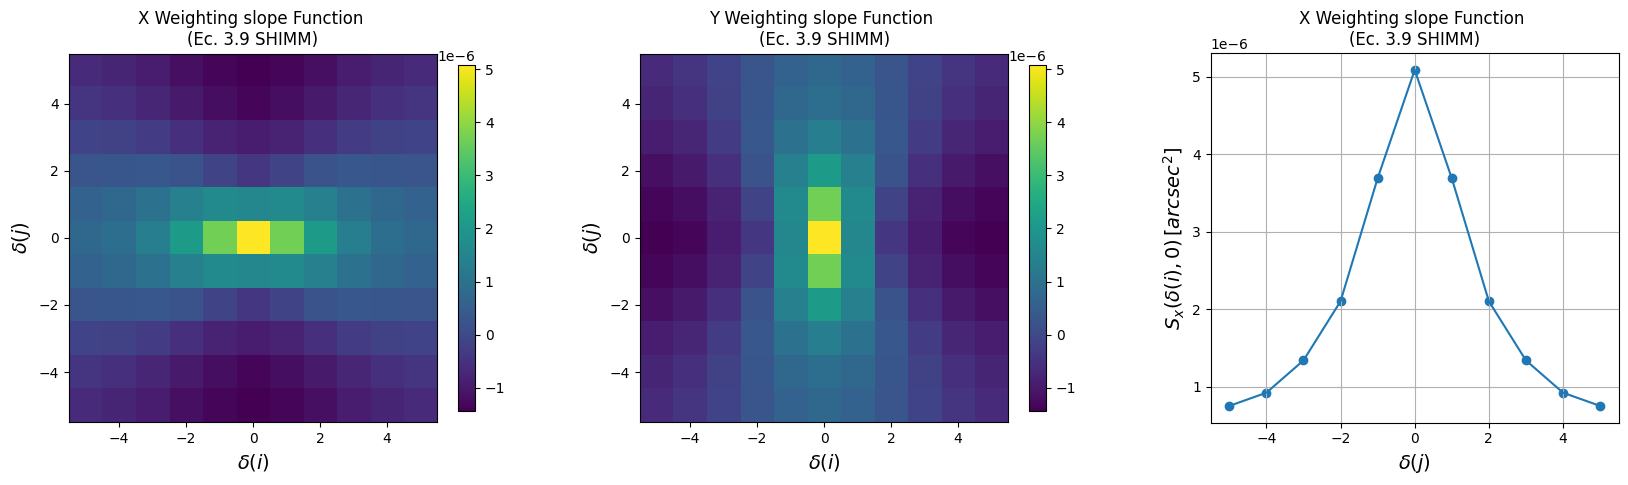

In [91]:
# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 
samp = 8    # sampling

tcov = calculate_weighting_function(d, nsubx,  glob = False)

GRID_SIZE = 2 * nsubx - 1 
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 3.9 SHIMM)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 3.9 SHIMM)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,5,:],)
ax3.scatter(np.arange(-5, 6),tcov[0,5,:],)
ax3.set_title('X Weighting slope Function \n(Ec. 3.9 SHIMM)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# G-tilt and Scintillation functions:

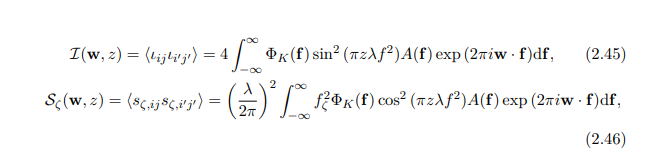

- cite: R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].

- ref: eq 2.45 Slopes Weighting function G-tilt
- ref: eq 2.46 scintillation Weighting function


In [110]:

def slope_weighting_function(d: float, nsubx: int, wavelength=500e-9, h=0, glob=False):

    """
    calculate weighting function (cov) for SCO-SLIDAR.
    
    Args:
        h (float)  : layer altitude    [m].
        d (float)  : sub-aperture size [m].
        glob (Bool): if you want to use a Phi_K with a global r0 or not
        nsubx (int): grid size.

    Returns:
    return  W_z (ndarray): [2,N,N]. where N = 2*nsubx-1 

    cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  
    cov[1, di, dj] -> cov_yy 

        
    """
    
    # 1. spatio-frequency domain (fx, fy)
    N = 2 * nsubx - 1                #<-- nyquis and lineal cov implementation [cycles]
    dx = d                           #<-- steps for all sub-aperture grid      [m]

    freq = np.fft.fftfreq(N, d=dx)   #<-- spatio-frequency vector based on sub-aperture grid size [cycles/m]
    fx, fy = np.meshgrid(freq, freq) 

    # spatio-frequency magnitude 
    f = np.hypot(fx,fy)   # f = ||f||
    f2 = f*f

    # ---------------------------------------------------------
    
    # 3. Shack-Hartmann Aperture filter (Ec. 2.44)
    A_f =  (np.sinc(d * fx)**2) * (np.sinc(d * fy)**2)
    
    # 4. propagation ( sinusoidal term in Ec. 2.42/2.45) fresnel phase param
    Fresnel_term = np.cos(np.pi * wavelength * h * f2)**2

    #5. Kolmogorov PSD 
    Phi_K = Kolmogorov_PSD(f,wavelength,glob)

    scaling = (wavelength/(np.pi*2))**2

    spectral_densityX = fy * fy * Phi_K * Fresnel_term * A_f * scaling
    spectral_densityY = fx * fx * Phi_K * Fresnel_term * A_f * scaling 

    # 6. Numerical solution using IFFT 
    covariance_mapX = np.fft.ifft2(spectral_densityX)
    covariance_mapY = np.fft.ifft2(spectral_densityY)
    
    # fftshift centra la frecuencia cero en el medio de la imagen para visualización
    covariance_mapX = np.fft.fftshift(covariance_mapX) 
    covariance_mapY = np.fft.fftshift(covariance_mapY) 
    
    scalingFactor = (206265.0)**2 

    # @Dev_Note: actualy, I am not sure if it is necesary to implement this scaling-factor
    W_zX = np.real(covariance_mapX) *  scalingFactor # X slope on [Rad^2] -> [arcsec^2]
    W_zY = np.real(covariance_mapY) *  scalingFactor # Y slope on [Rad^2] -> [arcsec^2]

    return np.array([W_zX,W_zY])



def scintillation_weighting_function(d: float, nsubx: int, wavelength=500e-9, h=0, glob=False):

    """
    Calcula la función de peso espacial (covarianza) para SCO-SLIDAR.
    
    Args:
        h (float)  : layer altitude    [m].
        d (float)  : sub-aperture size [m].
        glob (Bool): if you want to use a Phi_K with a global r0 or not
        nsubx (int): grid size.

    Returns:
    return  W_z (ndarray): [2,N,N]. where N = 2*nsubx-1 

    cov matrix for x-slope and y-slope .

    cov[0, di, dj] -> cov_xx  

        
    """
    
    # 1. spatio-frequency domain (fx, fy)
    N = 2 * nsubx - 1                #<-- nyquis and lineal cov implementation [cycles]
    dx = d                           #<-- steps for all sub-aperture grid      [m]

    freq = np.fft.fftfreq(N, d=dx)   #<-- spatio-frequency vector based on sub-aperture grid size [cycles/m]
    fx, fy = np.meshgrid(freq, freq) 

    # spatio-frequency magnitude 
    f = np.hypot(fx,fy)   # f = ||f||
    f2 = f*f
    
    # ---------------------------------------------------------
    
    # 3. aperture filter Shack-Hartmann (Ec. 2.44)
    A_f =  (np.sinc(d * fx)**2) * (np.sinc(d * fy)**2)
    
    # 4. propagation ( sinusoidal term in Ec. 2.42/2.45) fresnel phase param
    Fresnel_term = np.sin(np.pi * wavelength * h * f2)**2

    #5. Kolmogorov PSD obtain
    Phi_K = Kolmogorov_PSD(f,wavelength,glob)

    spectral_density = Phi_K * Fresnel_term * A_f * 4

    # 6. Numerical solution using IFFT 
    covariance_map = np.fft.ifft2(spectral_density)
    
    # fftshift centra la frecuencia cero en el medio de la imagen para visualización
    covariance_map = np.fft.fftshift(covariance_map) 
    
    scalingFactor = (206265.0)**2 
    # @Dev_Note: actualy, I am not sure if it is necesary to implement this scaling-factor
    W_z = np.real(covariance_map) *  scalingFactor # X slope on [Rad^2] -> [arcsec^2]

    print(W_z.shape)
    return W_z





# Example G-tilt:

---
@Dev_note: Similar to the previous implementation, the matrix structure looks similar, but the scale does not match. I understand that the result should differ for G-tilt, but I did not expect it to differ by this amount.

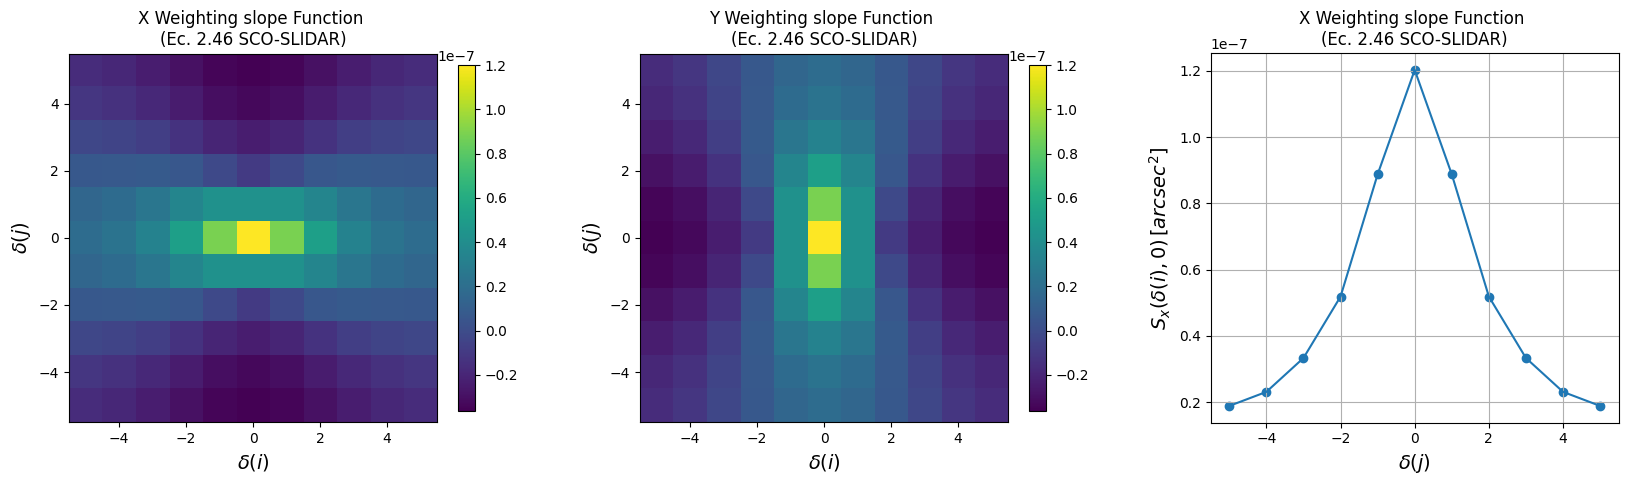

In [ ]:
# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 

tcov = slope_weighting_function(d, nsubx, wavelength=500e-9, h=0, glob = False)

GRID_SIZE = 2 * nsubx - 1
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov[1,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('Y Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov[0,5,:],)
ax3.scatter(np.arange(-5, 6),tcov[0,5,:],)
ax3.set_title('X Weighting slope Function \n(Ec. 2.46 SCO-SLIDAR)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

(11, 11)
(11, 11)


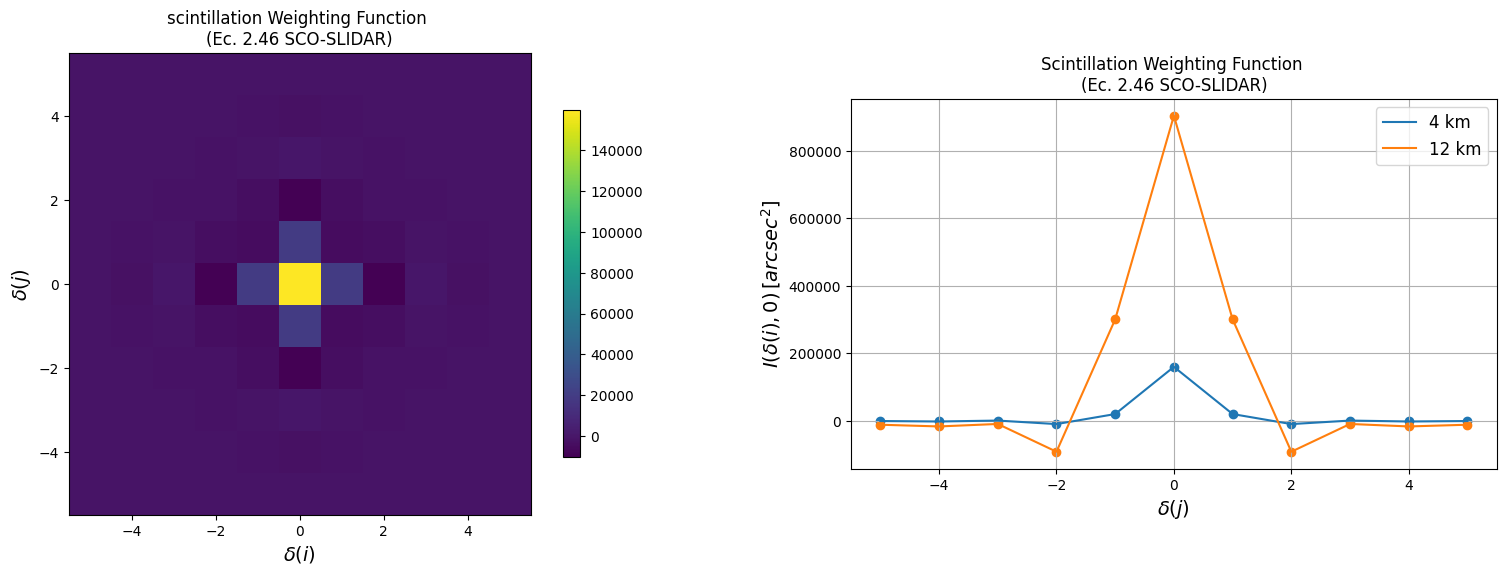

In [115]:
# --- Example params ---

d = 0.047   # sub-aperture size
nsubx = 6   # sub-apertures 
samp = 8    # sampling

tcov1 = scintillation_weighting_function(d, nsubx, wavelength=500e-9, h=4e3, glob = False)
tcov2 = scintillation_weighting_function(d, nsubx, wavelength=500e-9, h=12e3, glob = False)

GRID_SIZE = 2 * nsubx - 1
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov1,
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('scintillation Weighting Function \n(Ec. 2.46 SCO-SLIDAR)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(np.arange(-5, 6),tcov1[5,:],label="4 km")
ax2.scatter(np.arange(-5, 6),tcov1[5,:])
ax2.plot(np.arange(-5, 6),tcov2[5,:],label="12 km")
ax2.scatter(np.arange(-5, 6),tcov2[5,:])
ax2.legend(loc="best", fontsize=12)  
ax2.set_title('Scintillation Weighting Function \n(Ec. 2.46 SCO-SLIDAR)')
ax2.set_ylabel(r'$I(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.grid("on")

pos = ax2.get_position()
ax2.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])

# Tip-tilt Substraction(based on butterley code):


In [116]:
def ref_funcs_2d(cov: np.ndarray, pupil_mask: np.ndarray):
    """
    Replica la idea de slodar_refFuncs2D():
      - Proyecta cov a pares de sub-aperturas activas según pupil_mask
      - Aplica tip/tilt subtraction en la matriz de covarianza proyectada
      - Re-binea de vuelta a un mapa 2D por separación (nn x nn) promediando
    """
    nsubx = pupil_mask.shape[0]
    nn = 2 * nsubx - 1

    # índices de sub-aperturas activas
    active = [(i, j) for j in range(nsubx) for i in range(nsubx) if pupil_mask[j, i] > 0]
    nsubtot = len(active)

    psfs = np.zeros((2, nn, nn), dtype=np.float64)

    # pcov: matriz completa (nsubtot x nsubtot) para x e y intercalados
    pcov = np.zeros((nsubtot, nsubtot, 2), dtype=np.float64)

    # 1) llenar pcov tomando valores desde cov[2*delta] (x) y cov[2*delta+1] (y)
    for a, (i1, j1) in enumerate(active):
        for b, (i2, j2) in enumerate(active):
            di = i2 - i1 + (nsubx - 1)
            dj = j2 - j1 + (nsubx - 1)
            pcov[a, b, 0] = cov[0, di, dj]
            pcov[a, b, 1] = cov[1, di, dj]

    # 2) tip/tilt subtraction: C' = C - rowMean - colMean + globalMean
    row_mean = pcov.mean(axis=1, keepdims=True)   # (nsubtot,1,2)
    col_mean = pcov.mean(axis=0, keepdims=True)   # (1,nsubtot,2)
    glob_mean = pcov.mean(axis=(0, 1), keepdims=True)  # (1,1,2)
    pcov2 = pcov - row_mean - col_mean + glob_mean

    # 3) rebin a separaciones (nn x nn) 
    acc = np.zeros((nn, nn, 2), dtype=np.float64)
    cnt = np.zeros((nn, nn), dtype=np.int64)

    for a, (i1, j1) in enumerate(active):
        for b, (i2, j2) in enumerate(active):
            di = i2 - i1 + (nsubx - 1)
            dj = j2 - j1 + (nsubx - 1)

            acc[di, dj, :] += pcov2[a, b, :]
            cnt[di, dj] += 1

    # cnt>0
    m = cnt > 0
    psfs[0, m] = (acc[m, 0] / cnt[m])
    psfs[1, m] = (acc[m, 1] / cnt[m])

    return psfs

# Example with tip/tilt subsctraction:

---
@Dev_note: At this point, I compared both methods to identify the issue. In Figure 3, the Z-tilt and G-tilt curves were scaled by factors of 
1e5 and 1e6, respectively, so that they would be visible in the plot.

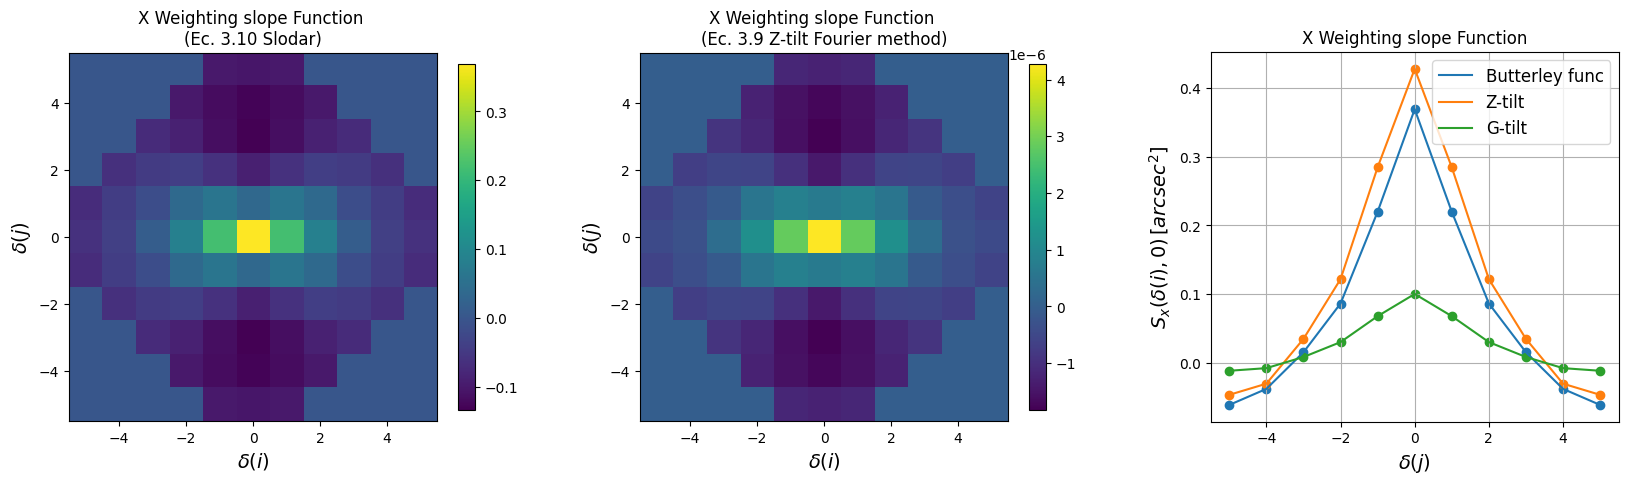

In [ ]:
nsubx = 6      # tamaño de la apertura
d = 0.047       # tamaño sub apertura
pupil =  np.array([[0,0,1,1,0,0],
                   [0,1,1,1,1,0],
                   [1,1,0,0,1,1],
                   [1,1,0,0,1,1],
                   [0,1,1,1,1,0],
                   [0,0,1,1,0,0]])


tcov = slopecov_kol(nsubx, samp, d) #<-- function call
Zcov = calculate_weighting_function(d, nsubx,  glob = False)
Gcov = slope_weighting_function(d, nsubx,  glob = False)

Bpsfs = ref_funcs_2d(tcov,pupil) # Butterley function
Zpsfs = ref_funcs_2d(Zcov,pupil) # Z-tilt function
Gpsfs = ref_funcs_2d(Gcov,pupil) # G-tilt function

GRID_SIZE = 2 * nsubx - 1 
BEAM = 1


# --- graphs ---
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(Bpsfs[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('X Weighting slope Function \n(Ec. 3.10 Slodar)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(Zpsfs[0,:,:],
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('X Weighting slope Function \n(Ec. 3.9 Z-tilt Fourier method)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),Bpsfs[0,5,:],label="Butterley func")
ax3.scatter(np.arange(-5, 6),Bpsfs[0,5,:],)
ax3.plot(np.arange(-5, 6),Zpsfs[0,5,:] * 1e5,label="Z-tilt")
ax3.scatter(np.arange(-5, 6),Zpsfs[0,5,:]* 1e5,)
ax3.plot(np.arange(-5, 6),Gpsfs[0,5,:] * 1e6,label="G-tilt")
ax3.scatter(np.arange(-5, 6),Gpsfs[0,5,:]* 1e6,)
ax3.legend(loc="best", fontsize=12) 
ax3.set_title('X Weighting slope Function')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])
